In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.nn.functional import mse_loss
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import os
import random

# 设置随机种子
random.seed(42)
torch.manual_seed(42)
np.random.seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# **Data Proprocessing**

In [3]:
# 加载数据
data_path = 'Full_Dataset_Updated.csv'  # 请根据实际路径修改
df_all = pd.read_csv(data_path, header=0)
df_all.rename(columns={df_all.columns[0]: 'time'}, inplace=True)
df_all['time'] = pd.to_datetime(df_all['time'], dayfirst=True)
df_all.set_index('time', inplace=True)

# 仅保留比利时本地特征
df_all['Gen_BE'] = df_all['Solar_BE'] + df_all['Wind_BE']
feature_cols = ['Price_BE', 'Gen_BE', 'Load_BE']
df = df_all[feature_cols].copy()

# 异常值处理（5-sigma 截断）
price_mean = df['Price_BE'].mean()
price_std = df['Price_BE'].std()
upper_limit = price_mean + 3 * price_std
lower_limit = price_mean - 3 * price_std
df.loc[df['Price_BE'] > upper_limit, 'Price_BE'] = upper_limit
df.loc[df['Price_BE'] < lower_limit, 'Price_BE'] = lower_limit

for col in feature_cols:
    # 先线性插值，限制连续缺失不超过 3 小时
    df[col] = df[col].interpolate(method='linear', limit=3)
    # 用前一天同一时刻的值填充剩余缺失（利用日周期）
    df[col] = df[col].fillna(df[col].shift(24))
    # 最后用前向/后向填充收尾
    df[col] = df[col].bfill().ffill()

In [4]:
df_all = df_all.dropna()  # 确保所有特征列都没有缺失值
for col in df_all.columns:
    if col != 'Price_BE':  # 价格不进行归一化
        print(f'{col}: {df_all["Price_BE"].corr(df_all[col]):.4f}')

Load_FR: 0.2005
Gen_FR: -0.1082
Price_CH: 0.9333
Wind_BE: -0.1900
Solar_BE: -0.2257
Load_BE: 0.2201
Gen_BE: -0.3138


In [5]:
# 构造滞后特征（参考第6章）
lags = [24, 48, 72] #] + list(range(24*7, 24*35, 24))  # 24h, 168h, 192h, ..., 816h
for var in ['Price_BE']:
    for lag in lags:
        df[f'{var}_lag_{lag}'] = df[var].shift(lag)
        feature_cols.append(f'{var}_lag_{lag}')

# 构造时间特征
lags = [24, 72] #] + list(range(24*7, 24*35, 24))  # 24h, 168h, 192h, ..., 816h
for var in ['Gen_BE', 'Load_BE']:
    for lag in lags:
        df[f'{var}_lag_{lag}'] = df[var].shift(lag)
        feature_cols.append(f'{var}_lag_{lag}')

import numpy as np

# 一天中的小时 (0-23)
df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)

# 一周中的星期 (0-6)
df['day_of_week_sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)

# 一个月中的第几天 (1-31)
df['day_of_month'] = df.index.day
df['day_of_month_sin'] = np.sin(2 * np.pi * df['day_of_month'] / 31)
df['day_of_month_cos'] = np.cos(2 * np.pi * df['day_of_month'] / 31)

# 一年中的月份 (1-12)
df['month'] = df.index.month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# 可选：一年中的第几天（已经包含月份信息，但有时也单独用）
df['day_of_year'] = df.index.dayofyear
df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)

# 选择要保留的时间特征（根据需要）
time_features = [
    #'hour_sin', 'hour_cos',
    # 'day_of_week_sin', 'day_of_week_cos',
    # 'day_of_year_sin', 'day_of_year_cos'
    #'day_of_month_sin', 'day_of_month_cos',
    # 'month_sin', 'month_cos'
]
# 可选择性加入 day_of_year 特征
# time_features += ['day_of_year_sin', 'day_of_year_cos']

feature_cols.extend(time_features)
# 注意：移除了原本的 'hour', 'day_of_week', 'day_of_year' 原始离散特征
# feature_cols.extend(time_features)

# 删除因滞后产生的缺失值
df = df.dropna()

In [6]:
for col in feature_cols:
    if col != 'Price_BE':  # 价格不进行归一化
        print(f'{col}: {df["Price_BE"].corr(df[col]):.4f}')

Gen_BE: -0.3340
Load_BE: 0.2316
Price_BE_lag_24: 0.8834
Price_BE_lag_48: 0.8188
Price_BE_lag_72: 0.7973
Gen_BE_lag_24: -0.2727
Gen_BE_lag_72: -0.2308
Load_BE_lag_24: 0.1714
Load_BE_lag_72: 0.0974


In [7]:
train_size = 8760
train_df = df.iloc[-train_size:].copy()
# val_df = df.iloc[-val_size-test_size:-test_size].copy()
# test_df = df.iloc[-test_size:].copy()

In [8]:
# 分离特征和目标
feature_cols = [col for col in feature_cols if col != 'Price_BE' and col != 'Price_CH']
X_train_raw = train_df[feature_cols].values
y_train_raw = train_df['Price_BE'].values.reshape(-1, 1)

In [9]:
def create_sequences(X, y, history_len=24, forecast_len=72):
    """
    X: 2D array of shape (total_timesteps, n_features)
    y: 1D array of shape (total_timesteps,)
    Returns:
        X_seq: shape (n_samples, history_len, n_features)
        y_seq: shape (n_samples, forecast_len)
    """
    X_seq, y_seq = [], []
    total = len(X) - history_len - forecast_len + 1
    for i in range(total):
        X_seq.append(X[i : i + history_len, :])
        y_seq.append(y[i + history_len : i + history_len + forecast_len].flatten())
    return np.array(X_seq), np.array(y_seq)

In [10]:
# 假设 X_train_scaled 形状为 (n_train, n_features)，y_train_scaled 形状为 (n_train,)
X_train_seq, y_train_seq = create_sequences(X_train_raw, y_train_raw)
print(f"X_train_seq shape: {X_train_seq.shape}")  # 应为 (样本数, 168, 特征数)
print(f"y_train_seq shape: {y_train_seq.shape}")  # 应为 (样本数, 72)

X_train_seq shape: (8665, 24, 9)
y_train_seq shape: (8665, 72)


In [11]:
# 转换为 Tensor，并调整形状为 (batch, channels, time) 以匹配你的模型
X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)  # (B, C, T)
y_train_t = torch.tensor(y_train_seq, dtype=torch.float32)
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
print(f"训练批次: {len(train_loader)}")

训练批次: 271


## **Training**

In [18]:
from model import ForecastModel
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ForecastModel(
    input_channels=len(feature_cols),
    history_len=24,
    forecast_len=72,
    window_sizes=[6, 8, 12]
).to(device)
model.load_state_dict(torch.load('results/forecast_model.pth', map_location=device))
model.train()
criterion = nn.HuberLoss(delta=5.)          # evaluation metric (MSE)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print(model)
print(f"Using device: {device}")

ForecastModel(
  (multi_scale_stft): MultiScaleSINE(
    (stft_layers): ModuleList(
      (0): Conv1d(1, 8, kernel_size=(6,), stride=(3,), padding=(3,), bias=False)
      (1): Conv1d(1, 10, kernel_size=(8,), stride=(4,), padding=(4,), bias=False)
      (2): Conv1d(1, 14, kernel_size=(12,), stride=(6,), padding=(6,), bias=False)
    )
  )
  (cnn): Sequential(
    (0): ResidualConv2d(
      (conv): Conv2d(27, 32, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), dilation=(2, 2))
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (shortcut): Conv2d(27, 32, kernel_size=(1, 1), stride=(1, 1))
    )
    (1): ChannelAttention(
      (avg_pool): AdaptiveAvgPool2d(output_size=1)
      (max_pool): AdaptiveMaxPool2d(output_size=1)
      (fc): Sequential(
        (0): Linear(in_features=32, out_features=8, bias=True)
        (1): ReLU()
        (2): Linear(in_features=8, out_features=32, bias=True)
        (3): Sigmoid()
      )


In [19]:
num_epochs = 500
best_train_loss = float('inf')
best_model_path = 'results/finetune_forecast_model.pth'
patience_counter = 0
early_stop_patience = 500

train_losses, val_losses = [], []

for epoch in range(num_epochs):
    # 训练
    model.train()
    total_train = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_train += loss.item() * xb.size(0)
        del xb, yb, pred, loss
        torch.cuda.empty_cache()
    avg_train = total_train / len(train_loader.dataset)
    train_losses.append(avg_train)

    # 保存最佳模型
    if avg_train < best_train_loss:
        best_train_loss = avg_train
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
        print(f"Epoch {epoch+1}: 保存新最佳模型，验证损失 = {best_train_loss:.6f}")
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print(f"早停于 epoch {epoch+1}")
            break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | 训练损失: {avg_train:.6f}")

Epoch 1: 保存新最佳模型，验证损失 = 101.201619
Epoch 2: 保存新最佳模型，验证损失 = 94.191587
Epoch 3: 保存新最佳模型，验证损失 = 92.009292
Epoch 4: 保存新最佳模型，验证损失 = 90.564639
Epoch 5: 保存新最佳模型，验证损失 = 89.701402
Epoch 6: 保存新最佳模型，验证损失 = 88.684745
Epoch 7: 保存新最佳模型，验证损失 = 87.647182
Epoch 8: 保存新最佳模型，验证损失 = 87.019030
Epoch 9: 保存新最佳模型，验证损失 = 86.336799
Epoch 10: 保存新最佳模型，验证损失 = 85.671598
Epoch 10/500 | 训练损失: 85.671598
Epoch 11: 保存新最佳模型，验证损失 = 84.955785
Epoch 12: 保存新最佳模型，验证损失 = 84.504384
Epoch 13: 保存新最佳模型，验证损失 = 83.442397
Epoch 15: 保存新最佳模型，验证损失 = 82.439205
Epoch 16: 保存新最佳模型，验证损失 = 82.086820
Epoch 17: 保存新最佳模型，验证损失 = 81.386446
Epoch 18: 保存新最佳模型，验证损失 = 81.360194
Epoch 19: 保存新最佳模型，验证损失 = 80.021211
Epoch 20: 保存新最佳模型，验证损失 = 79.701208
Epoch 20/500 | 训练损失: 79.701208
Epoch 21: 保存新最佳模型，验证损失 = 79.100904
Epoch 23: 保存新最佳模型，验证损失 = 78.908703
Epoch 24: 保存新最佳模型，验证损失 = 78.292284
Epoch 25: 保存新最佳模型，验证损失 = 77.491906
Epoch 26: 保存新最佳模型，验证损失 = 77.014337
Epoch 28: 保存新最佳模型，验证损失 = 76.459077
Epoch 29: 保存新最佳模型，验证损失 = 75.931825
Epoch 30/500 | 训练损失: 75.999379
Epoch

## **Testing**

In [20]:
# true = scaler_y.inverse_transform(y_test_seq[-1].reshape(-1, 1))                   # (72,)
true = y_train_seq[-1].reshape(-1, 1)  # (72,)

In [21]:
model.load_state_dict(torch.load('results/finetune_forecast_model.pth', map_location=device))
model.eval()

# ---------------------------
# 3. 收集所有预测值和真实值
# ---------------------------
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        outputs = model(X_batch)          # shape: (batch_size, 24)
        all_preds.append(outputs.cpu().numpy())
        all_targets.append(y_batch.cpu().numpy())

all_preds = np.concatenate(all_preds, axis=0)     # (N, 24)
all_targets = np.concatenate(all_targets, axis=0) # (N, 72)

In [22]:
# 获取测试集最后一个窗口
last_window = X_train_seq[-1]                    # (168, 11) 注意现在的特征数可能是11
last_tensor = torch.tensor(last_window, dtype=torch.float32).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    # 预测出的是归一化值，需要逆转换
    pred_scaled = model(last_tensor).cpu().numpy()     # (1, 72)
    pred_future = pred_scaled.reshape(-1,1)# scaler_y.inverse_transform(pred_scaled).reshape(-1, 1) #pred_scaled.reshape(-1,1)# red_scaled.reshape(-1,1)#

# 保存要求的结果

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(all_targets, all_preds)
mse = mean_squared_error(all_targets, all_preds)
rmse = np.sqrt(mean_squared_error(all_targets, all_preds))

# 计算 WMAPE (综合绝对百分比误差，规避分母为 0 的坑)
wmape = np.sum(np.abs(all_preds - all_targets)) / np.sum(np.abs(all_targets))
# 计算 sMAPE
epsilon = 1e-8
smape = np.mean(2.0 * np.abs(all_preds - all_targets) / (np.abs(all_preds) + np.abs(all_targets) + epsilon))

from sklearn.metrics import r2_score
r2 = r2_score(all_targets, all_preds)

print("\n--- Forecast Model Performance ---")
print(f"MSE: {mse:.6f}")
print(f"MAE:   {mae:.4f} EUR/MWh")
print(f"RMSE:  {rmse:.4f} EUR/MWh")
print(f"WMAPE: {wmape:.4f}")
print(f"sMAPE: {smape:.4f}")
print(f"R²:    {r2:.4f}")


--- Forecast Model Performance ---
MSE: 314.795319
MAE:   11.9438 EUR/MWh
RMSE:  17.7425 EUR/MWh
WMAPE: 0.1452
sMAPE: 0.2856
R²:    0.8387


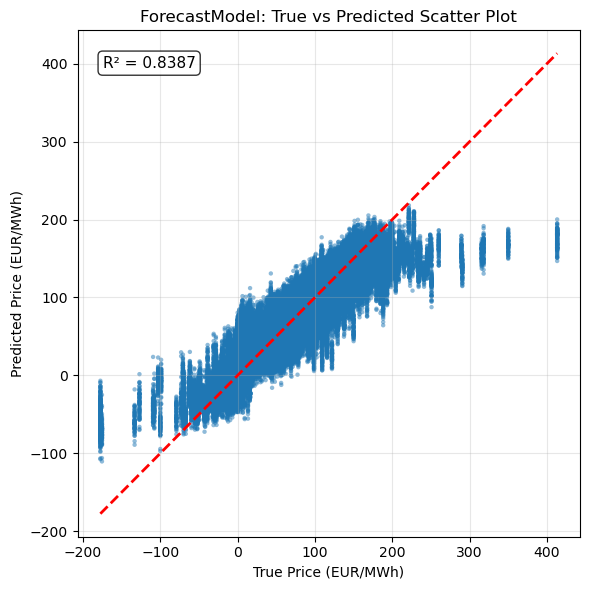

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 假设 true 和 pred 是 NumPy 数组，形状均为 (N,) 或 (N,1)
# 如果 shape 是 (N,1)，可以先 flatten
true_flat = all_targets.flatten()
pred_flat = all_preds.flatten()

# 计算 Pearson 相关系数
corr, p_value = pearsonr(true_flat, pred_flat)

# 绘制散点图
plt.figure(figsize=(6, 6))
plt.scatter(true_flat, pred_flat, alpha=0.5, s=10, edgecolors='none')
plt.plot([true_flat.min(), true_flat.max()],
         [true_flat.min(), true_flat.max()],
         'r--', lw=2, label='Perfect fit')

# 添加相关系数文本
# \plt.text(0.05, 0.95,
#          transform=plt.gca().transAxes, fontsize=12,
#         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.xlabel('True Price (EUR/MWh)')
plt.ylabel('Predicted Price (EUR/MWh)')
plt.title('ForecastModel: True vs Predicted Scatter Plot')
plt.grid(True, alpha=0.3)
ax = plt.gca()  # 或者使用已有的 axes 对象
ax.text(0.05, 0.95, f'R² = {r2:.4f}',
        transform=ax.transAxes,        # 关键！
        fontsize=11,
        verticalalignment='top',       # 顶部对齐
        horizontalalignment='left',    # 左对齐（默认就是 left）
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig('./result/finetune_scatter_plot.png', dpi=300)
plt.show()

In [28]:
last_window = X_train_raw[-24:]
print(last_window.shape)# (168, 11) 注意现在的特征数可能是11
last_tensor = torch.tensor(last_window, dtype=torch.float32).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    # 预测出的是归一化值，需要逆转换
    pred_scaled = model(last_tensor).cpu().numpy()     # (1, 72)
    pred_future = pred_scaled.reshape(-1,1)# scaler_y.inverse_transform(pred_scaled).reshape(-1, 1) #pred_scaled.reshape(-1,1)# red_scaled.reshape(-1,1)#

# 保存要求的结果
np.savetxt('predictions.csv', pred_future, delimiter=',', fmt='%.6f')
print("predictions.csv saved with 72 hourly forecasts (Real Scale).")

(24, 9)
predictions.csv saved with 72 hourly forecasts (Real Scale).


In [39]:
y_train_raw[-72:]

array([[ 1.083000e+02],
       [ 1.048200e+02],
       [ 1.020300e+02],
       [ 1.040825e+02],
       [ 1.078575e+02],
       [ 1.143900e+02],
       [ 1.071550e+02],
       [ 9.727500e+01],
       [ 5.706750e+01],
       [ 9.932500e+00],
       [-1.250000e-02],
       [-4.250000e-02],
       [-9.250000e-02],
       [-1.250000e-02],
       [ 2.500000e-03],
       [ 2.033500e+01],
       [ 7.064500e+01],
       [ 1.096825e+02],
       [ 1.249475e+02],
       [ 1.368675e+02],
       [ 1.325475e+02],
       [ 1.268075e+02],
       [ 1.182500e+02],
       [ 1.161250e+02],
       [ 1.127725e+02],
       [ 1.071300e+02],
       [ 1.062800e+02],
       [ 9.710000e+01],
       [ 9.669500e+01],
       [ 1.009225e+02],
       [ 8.955500e+01],
       [ 5.682250e+01],
       [ 1.118000e+01],
       [ 1.500000e-02],
       [ 1.750000e-01],
       [ 4.625000e-01],
       [-1.325000e-01],
       [-3.075000e-01],
       [-2.525000e-01],
       [ 2.200000e+00],
       [ 5.278000e+01],
       [ 8.78625

In [26]:
pred_future

array([[ 86.40071 ],
       [ 80.10704 ],
       [ 74.15373 ],
       [ 74.18601 ],
       [ 89.22759 ],
       [112.58772 ],
       [126.91003 ],
       [121.26972 ],
       [ 99.856804],
       [ 66.82858 ],
       [ 36.166073],
       [ 17.656326],
       [  8.896354],
       [ 10.985676],
       [ 19.065315],
       [ 36.878963],
       [ 65.20946 ],
       [ 99.19873 ],
       [123.16462 ],
       [133.38272 ],
       [126.977585],
       [113.33533 ],
       [101.397514],
       [ 92.06955 ],
       [ 85.44187 ],
       [ 79.21097 ],
       [ 73.398865],
       [ 74.56342 ],
       [ 90.24352 ],
       [113.787605],
       [126.55563 ],
       [121.58108 ],
       [ 96.46358 ],
       [ 64.07453 ],
       [ 35.032345],
       [ 17.270046],
       [  9.627024],
       [ 12.96001 ],
       [ 24.433458],
       [ 44.393715],
       [ 75.07783 ],
       [111.45351 ],
       [138.76619 ],
       [152.89987 ],
       [151.43124 ],
       [140.28433 ],
       [129.82344 ],
       [121.9

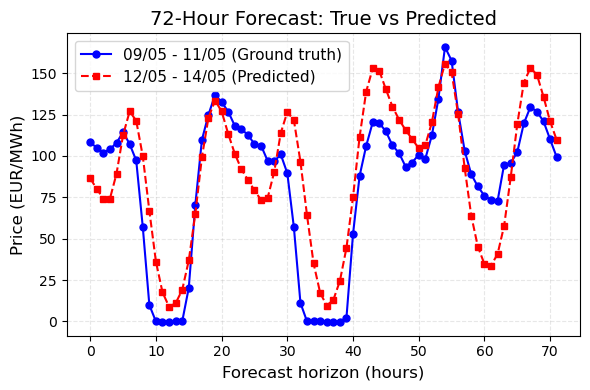

In [27]:
plt.figure(figsize=(6,4))
# 真实值：蓝色实线 + 圆点
plt.plot(y_train_raw[-72:], 'o-', markersize=5, linewidth=1.5, color='blue', label='09/05 - 11/05 (Ground truth)')
    # 预测值：红色虚线 + 方块
plt.plot(pred_future, 's--', markersize=5, linewidth=1.5, color='red', label='12/05 - 14/05 (Predicted)')
plt.xlabel('Forecast horizon (hours)', fontsize=12)
plt.ylabel('Price (EUR/MWh)', fontsize=12)
plt.title('72-Hour Forecast: True vs Predicted', fontsize=14)
plt.legend(fontsize=11, loc='best')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
path = os.path.join('./results/finetune_forecast.pdf')
os.makedirs(os.path.dirname(path), exist_ok=True)
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()